In [1]:
import torch
import matplotlib.pyplot as plt
from torch import nn
import numpy as np

## 1. Getting Data Ready
(Date - 31/ Mar/2026)

In [2]:
weight = 0.7
bias = 0.3

start = 0
end = 1
step = 0.02
X = torch.arange(start, end, step).unsqueeze(dim=1)
Y = weight * X + bias

In [3]:
train_split = int(0.8 * len(X))
X_train, Y_train = X[:train_split], Y[:train_split]
X_test, Y_test = X[train_split:], Y[train_split:]

In [4]:
Y_test

tensor([[0.8600],
        [0.8740],
        [0.8880],
        [0.9020],
        [0.9160],
        [0.9300],
        [0.9440],
        [0.9580],
        [0.9720],
        [0.9860]])

In [5]:
def plot_predictions(train_data=X_train, 
                     train_labels=Y_train, 
                     test_data=X_test, 
                     test_labels=Y_test, 
                     predictions=None):
  """
  Plots training data, test data and compares predictions.
  """
  plt.figure(figsize=(10, 7))

  # Plot training data in blue
  #               X            Y
  plt.scatter(train_data, train_labels, c="b", s=4, label="Training data")
  
  # Plot test data in green
  #               X           Y
  plt.scatter(test_data, test_labels, c="g", s=4, label="Testing data")

  if predictions is not None:
    # Plot the predictions in red (predictions were made on the test data)
    plt.scatter(test_data, predictions, c="r", s=4, label="Predictions")

  # Show the legend
  plt.legend(prop={"size": 14})

## 2. Building model

In [6]:
# Create a linear regression model class
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,
                                               requires_grad = True,
                                               dtype=torch.float))
        
        self.bias = nn.Parameter(torch.randn(1,
                                             requires_grad=True,
                                             dtype=torch.float))
        
    # Forward method to define the computation in the model
    def forward(self, X: torch.Tensor) -> torch.Tensor:
        return self.weights * X + self.bias # -> Linear regression formula

### PyTorch model building essentials 
(Date- 1/Mar/2026)

In [7]:
torch.manual_seed(42)

model_0 = LinearRegressionModel()
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [8]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

### Making prediction using `torch.inference_mode()`

In [9]:
X_test, Y_test

(tensor([[0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.8600],
         [0.8740],
         [0.8880],
         [0.9020],
         [0.9160],
         [0.9300],
         [0.9440],
         [0.9580],
         [0.9720],
         [0.9860]]))

In [10]:
y_preds = model_0(X_test)
y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]], grad_fn=<AddBackward0>)

In [11]:
with torch.inference_mode():
    y_preds = model_0(X_test)

# with torch.no_grad():
#     y_preds = model_0(X_test)

y_preds

tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])

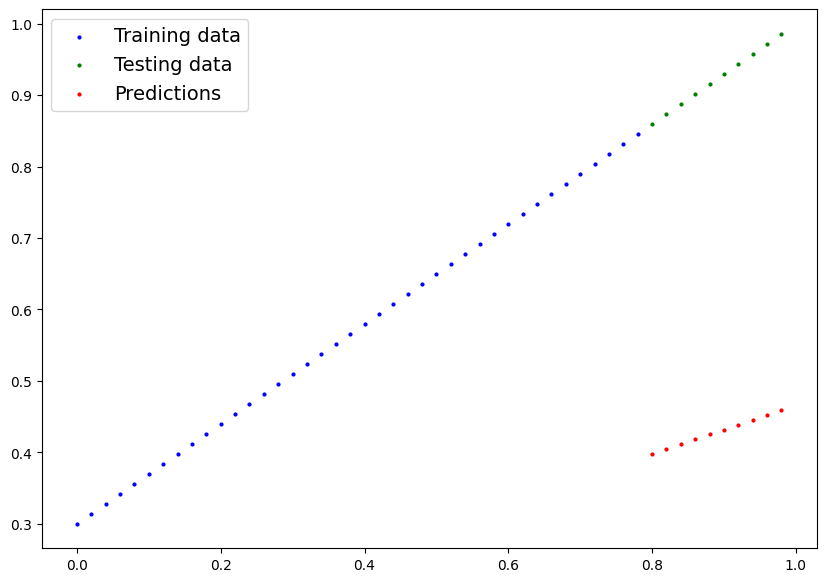

In [12]:
plot_predictions(predictions = y_preds) 

## 3. Train a model 
(Date - 2/Apr/2026)

The whole idea of training a model is to make the parameters better represent the data (or make the parameters as close as to the ideal values).

We're going to use a loss function. It may also be refered to as a cost function or a criterion by different people.

* **Loss function:** A function that tells how wrong our model's predictions are as compared to the actual values.

    _**Loss_function() = (actual_value - predicted value)^2**_

* **Optimizer:** Takes into the account the loss of a model and adjust the model's parameters (e.g. weights and biases) to improve the loss function (i.e. decreasing the output of the loss function).

Specifically for Pytorch, we need:
  * A training loop
  * A testing loop



In [13]:
# Setting up a loss function
loss_fn = nn.L1Loss()
print(loss_fn)

# Setting up an optimizer (stochastic gradient descent)
optimizer = torch.optim.SGD(params=model_0.parameters(),
                            lr=0.01)
print(optimizer)

L1Loss()
SGD (
Parameter Group 0
    dampening: 0
    differentiable: False
    foreach: None
    fused: None
    lr: 0.01
    maximize: False
    momentum: 0
    nesterov: False
    weight_decay: 0
)


### Building a training loop

A couple of things we need in a trainig loop:

0. Loop through the data and do...
1. Forward pass (this involves data moving through our model's `forward()` functions) to make predictions on data - also called forward propagation.
2. Calculate the loss.
3. Optimzer zero grad
4. Loss backward - move backwards throught the network to calculate the gradients of each of the parameters of our model with respect to the loss. -> **Backpropagation**
5. Optimizer step - use the optimizer to adjust our model's parameters to try and improve the loss -> **Gradient descent**

In [ ]:
# An epoch is one loop through the data... (this is a hyperparameter - because we set it ourselves, instead of our model setting it itself)
epochs = 200
epoch_count = []
loss_values = []
test_loss_values = []
# 0. Loop through the data
for epoch in range(epochs):
    model_0.train() # train mode in PyTorch sets all parameters that require gradients to require gradients.
    
    # 1. Forward pass
    y_pred = model_0(X_train)

    # 2. Calculate the loss
    loss = loss_fn(y_pred, Y_train)

    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Backpropagation
    loss.backward()

    # 5. Gradient descent
    optimizer.step()

    model_0.eval() # Turns off gradient tracking
    with torch.inference_mode():
        test_pred = model_0(X_test)
        test_loss = loss_fn(test_pred, Y_test)
    if epoch % 10 == 0:
        epoch_count.append(epoch)
        loss_values.append(loss)
        test_loss_values.append(test_loss)
        print(f"Epoch : {epoch} | Loss: {loss} | Test loss {test_loss}")

print(model_0.state_dict())
loss, # y_pred.detach()

Epoch : 0 | Loss: 0.31288138031959534 | Test loss 0.48106518387794495
Epoch : 10 | Loss: 0.1976713240146637 | Test loss 0.3463551998138428
Epoch : 20 | Loss: 0.08908725529909134 | Test loss 0.21729660034179688
Epoch : 30 | Loss: 0.053148526698350906 | Test loss 0.14464017748832703
Epoch : 40 | Loss: 0.04543796554207802 | Test loss 0.11360953003168106
Epoch : 50 | Loss: 0.04167863354086876 | Test loss 0.09919948130846024
Epoch : 60 | Loss: 0.03818932920694351 | Test loss 0.08886633068323135
Epoch : 70 | Loss: 0.03476089984178543 | Test loss 0.0805937647819519
Epoch : 80 | Loss: 0.03132382780313492 | Test loss 0.07232122868299484
Epoch : 90 | Loss: 0.02788739837706089 | Test loss 0.06473556160926819
Epoch : 100 | Loss: 0.024458957836031914 | Test loss 0.05646304413676262
Epoch : 110 | Loss: 0.021020207554101944 | Test loss 0.04819049686193466
Epoch : 120 | Loss: 0.01758546568453312 | Test loss 0.04060482233762741
Epoch : 130 | Loss: 0.014155393466353416 | Test loss 0.03233227878808975
Ep

(tensor(0.0026, grad_fn=<MeanBackward0>),)

## 4. Testing the model 
(Date - 3/Apr/2026)

In [15]:
# epoch_count = []
# test_loss_values = []
# model_0.eval() # Turns off gradient tracking
# with torch.inference_mode():
#     test_pred = model_0(X_test)
#     test_loss = loss_fn(test_pred, Y_test)
#     epoch_count.append(epoch)
#     test_loss_values.append(test_loss)
    
# test_loss

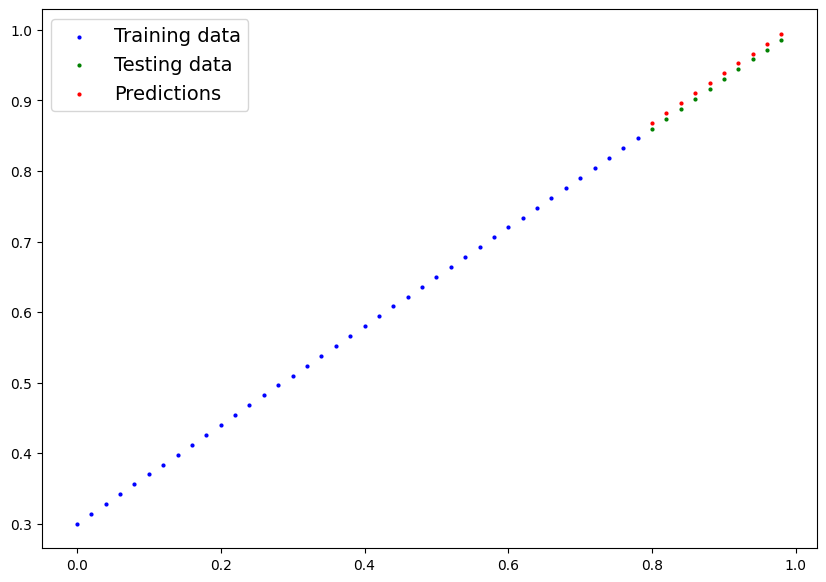

In [16]:
plot_predictions(predictions=test_pred)


(Date - 4/Apr/2026)

C:\Users\user\AppData\Local\Temp\ipykernel_4976\2103054391.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\generated\python_variable_methods.cpp:837.)
  plt.plot(epoch_count, torch.tensor(loss_values).detach(), label="Train loss")


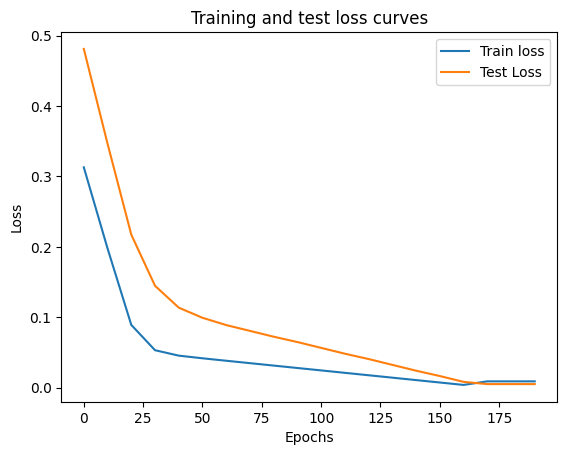

In [17]:
# Plot the loss curves
plt.plot(epoch_count, torch.tensor(loss_values).detach(), label="Train loss")
plt.plot(epoch_count, torch.tensor(test_loss_values).detach(), label="Test Loss")
plt.title("Training and test loss curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

## 5. Saving and loading a model 
(Date - 5/Apr/2026)

There are three main methods you should know about for saving and loading models in PyTorch:
1. `torch.save()` - allows you to save a PyTorch object in Python's pickle format.
2. `torch.load()` - allows you to load a saved PyTorch object.
3. `torch.nn.Module.load_state_dict()` - this allows you to load a model's saved state dictionary.

### i. Saving a model

In [18]:
# Saving our PyTorch model
from pathlib import Path

# 1. Create model's directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

# 2. Create model save path
MODEL_NAME = "Gradient_Descent_Model.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

# 3. Save the model's state dict
print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(obj=model_0.state_dict(),
           f=MODEL_SAVE_PATH)
print(MODEL_SAVE_PATH)

Saving model to: models\Gradient_Descent_Model.pth
models\Gradient_Descent_Model.pth


### ii. Loading our model 
(Date - 6/Apr/2026)

In [19]:
# To load in a saved state_dict, we have to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()

# Load the saved state_dict of model_0
loaded_model_0.load_state_dict(torch.load(f=MODEL_SAVE_PATH))
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [20]:
# Let's make some predictions with our loaded model
loaded_model_0.eval()
with torch.inference_mode():
    loaded_model_preds = loaded_model_0(X_test)

loaded_model_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [21]:
test_pred == loaded_model_preds

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

SUMMARY IN 21.IPYNB